In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [ ]:
df=pd.read_csv("/content/Transactions.csv")
df.head()

,TransactionID,CustomerID,ProductID,TransactionDate,Quantity,TotalValue,Price
0,T00001,C0199,P067,2024-08-25 12:38:23,1,300.68,300.68
1,T00112,C0146,P067,2024-05-27 22:23:54,1,300.68,300.68
2,T00166,C0127,P067,2024-04-25 07:38:55,1,300.68,300.68
3,T00272,C0087,P067,2024-03-26 22:55:37,2,601.36,300.68
4,T00363,C0070,P067,2024-03-21 15:10:10,3,902.04,300.68


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TransactionID    1000 non-null   object 
 1   CustomerID       1000 non-null   object 
 2   ProductID        1000 non-null   object 
 3   TransactionDate  1000 non-null   object 
 4   Quantity         1000 non-null   int64  
 5   TotalValue       1000 non-null   float64
 6   Price            1000 non-null   float64
dtypes: float64(2), int64(1), object(4)
memory usage: 54.8+ KB


In [ ]:
print(df.isnull().sum())

print(df.duplicated().sum())

TransactionID      0
CustomerID         0
ProductID          0
TransactionDate    0
Quantity           0
TotalValue         0
Price              0
dtype: int64
0


In [ ]:
df.describe()

,Quantity,TotalValue,Price
count,1000.000000,1000.000000,1000.00000
mean,2.537000,689.995560,272.55407
std,1.117981,493.144478,140.73639
min,1.000000,16.080000,16.08000
25%,2.000000,295.295000,147.95000
50%,3.000000,588.880000,299.93000
75%,4.000000,1011.660000,404.40000
max,4.000000,1991.040000,497.76000


In [ ]:
df['Order_date']=pd.to_datetime(df['TransactionDate'])
df.head()

,TransactionID,CustomerID,ProductID,TransactionDate,Quantity,TotalValue,Price,Order_date
0,T00001,C0199,P067,2024-08-25 12:38:23,1,300.68,300.68,2024-08-25 12:38:23
1,T00112,C0146,P067,2024-05-27 22:23:54,1,300.68,300.68,2024-05-27 22:23:54
2,T00166,C0127,P067,2024-04-25 07:38:55,1,300.68,300.68,2024-04-25 07:38:55
3,T00272,C0087,P067,2024-03-26 22:55:37,2,601.36,300.68,2024-03-26 22:55:37
4,T00363,C0070,P067,2024-03-21 15:10:10,3,902.04,300.68,2024-03-21 15:10:10


In [ ]:
df['Order_date']=df['Order_date'].dt.date
df.head()

,TransactionID,CustomerID,ProductID,TransactionDate,Quantity,TotalValue,Price,Order_date
0,T00001,C0199,P067,2024-08-25 12:38:23,1,300.68,300.68,2024-08-25
1,T00112,C0146,P067,2024-05-27 22:23:54,1,300.68,300.68,2024-05-27
2,T00166,C0127,P067,2024-04-25 07:38:55,1,300.68,300.68,2024-04-25
3,T00272,C0087,P067,2024-03-26 22:55:37,2,601.36,300.68,2024-03-26
4,T00363,C0070,P067,2024-03-21 15:10:10,3,902.04,300.68,2024-03-21


In [ ]:
df['Order_date'].max()

datetime.date(2024, 12, 28)

In [ ]:
df['Order_date'].min()

datetime.date(2023, 12, 30)

In [ ]:
df['Quantity'].value_counts()

,count
Quantity,
4,261
3,254
2,246
1,239


In [ ]:
reference_date = df["Order_date"].max() + pd.Timedelta(days=1)
print(reference_date)

2024-12-29


In [ ]:
rfm = df.groupby("CustomerID").agg({
    "Order_date": lambda x: (reference_date - x.max()).days,  # Recency
    "Quantity": "nunique",  # Frequency
    "TotalValue": "sum"  # Monetary
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
C0001            57          2   3354.52
C0002            26          2   1862.74
C0003           127          2   2725.38
C0004             6          4   5354.88
C0005            55          2   2034.24


In [ ]:
# Recency Score (lower is better → reverse labels)
rfm["R_Score"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1])

# Frequency Score
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])

# Monetary Score
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5])

In [ ]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
C0001,57,2,3354.52,3,1,3
C0002,26,2,1862.74,4,1,1
C0003,127,2,2725.38,1,1,2
C0004,6,4,5354.88,5,4,5
C0005,55,2,2034.24,3,1,2


In [ ]:
rfm.tail()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
C0196,14,3,4982.88,5,4,4
C0197,2,3,1928.65,5,4,1
C0198,86,2,931.83,2,2,1
C0199,64,3,1979.28,3,4,2
C0200,18,3,4758.60,4,4,4


In [ ]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

print(rfm.head())

            Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
CustomerID                                                                
C0001            57          2   3354.52       3       1       3       313
C0002            26          2   1862.74       4       1       1       411
C0003           127          2   2725.38       1       1       2       112
C0004             6          4   5354.88       5       4       5       545
C0005            55          2   2034.24       3       1       2       312


In [ ]:
def segment_customer(row):
    if row["RFM_Score"] == "555":
        return "Champions"
    elif row["R_Score"] >= 4 and row["F_Score"] >= 4:
        return "Loyal Customers"
    elif row["R_Score"] >= 4:
        return "Recent Customers"
    elif row["F_Score"] >= 4:
        return "Frequent Customers"
    elif row["M_Score"] >= 4:
        return "Big Spenders"
    else:
        return "At Risk"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

print(rfm["Segment"].value_counts())

Segment
At Risk               60
Recent Customers      37
Frequent Customers    37
Loyal Customers       35
Big Spenders          22
Champions              8
Name: count, dtype: int64


In [ ]:
# Top customers
top_customers = rfm.sort_values("Monetary", ascending=False).head(10)

# At-risk customers
at_risk = rfm[rfm["Segment"] == "At Risk"]

# Loyal customers
loyal = rfm[rfm["Segment"] == "Loyal Customers"]

In [ ]:
at_risk

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
C0001,57,2,3354.52,3,1,3,313,At Risk
C0003,127,2,2725.38,1,1,2,112,At Risk
C0005,55,2,2034.24,3,1,2,312,At Risk
C0007,126,3,2579.82,1,2,2,122,At Risk
C0009,78,1,896.50,3,1,1,311,At Risk
C0014,347,1,318.66,1,1,1,111,At Risk
C0015,99,2,1157.48,2,1,1,211,At Risk
C0019,51,3,2185.82,3,2,2,322,At Risk
C0020,334,1,922.41,1,1,1,111,At Risk


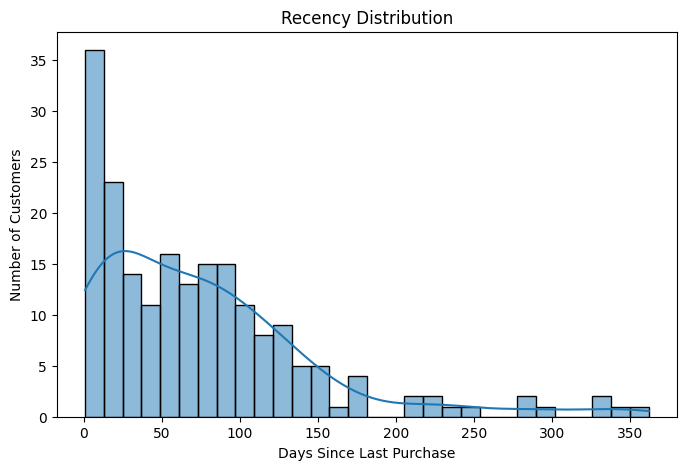

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(rfm["Recency"], bins=30, kde=True)
plt.title("Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")
plt.show()

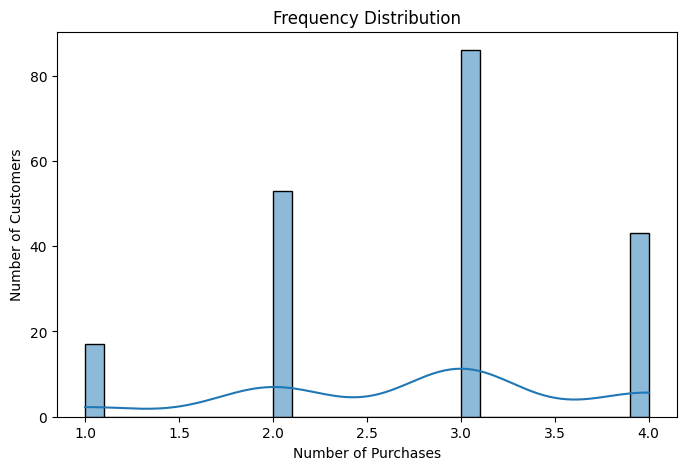

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(rfm["Frequency"], bins=30, kde=True)
plt.title("Frequency Distribution")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.show()

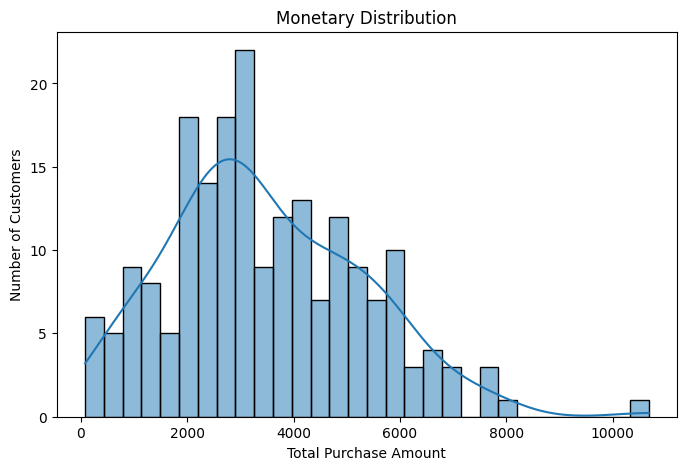

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(rfm["Monetary"], bins=30, kde=True)
plt.title("Monetary Distribution")
plt.xlabel("Total Purchase Amount")
plt.ylabel("Number of Customers")
plt.show()

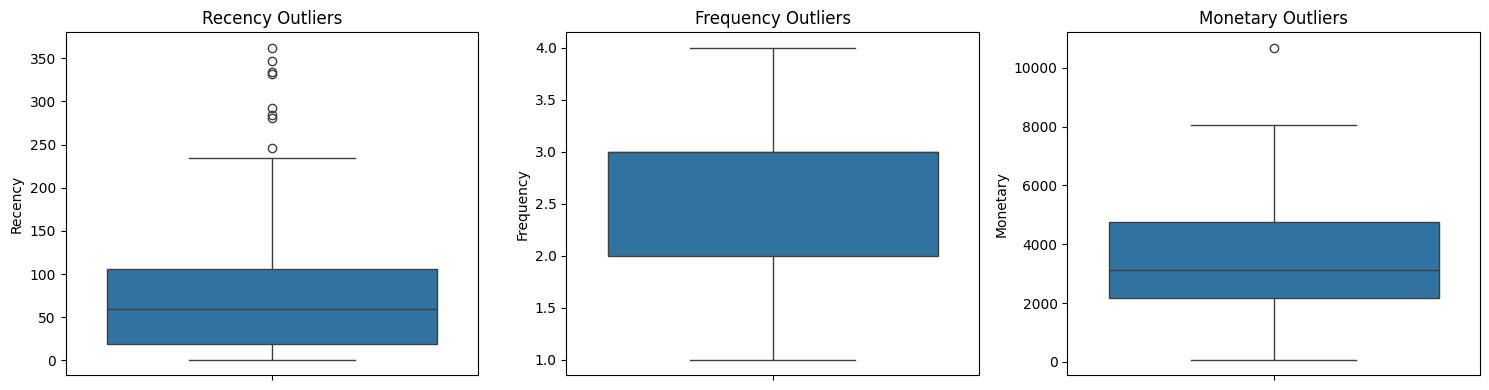

In [ ]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.boxplot(y=rfm["Recency"])
plt.title("Recency Outliers")

plt.subplot(1,3,2)
sns.boxplot(y=rfm["Frequency"])
plt.title("Frequency Outliers")

plt.subplot(1,3,3)
sns.boxplot(y=rfm["Monetary"])
plt.title("Monetary Outliers")

plt.tight_layout()
plt.show()

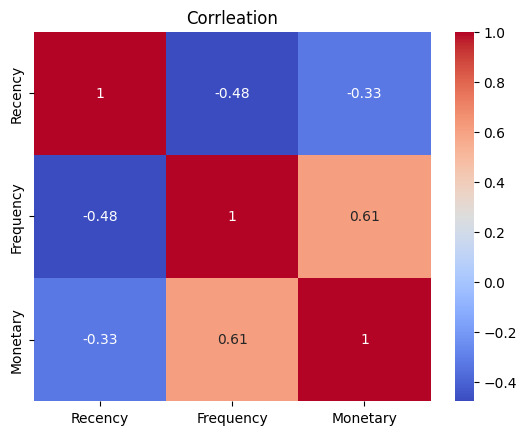

In [ ]:
sns.heatmap(rfm[['Recency','Frequency','Monetary']].corr(),annot=True,cmap='coolwarm')
plt.title("Corrleation")
plt.show()

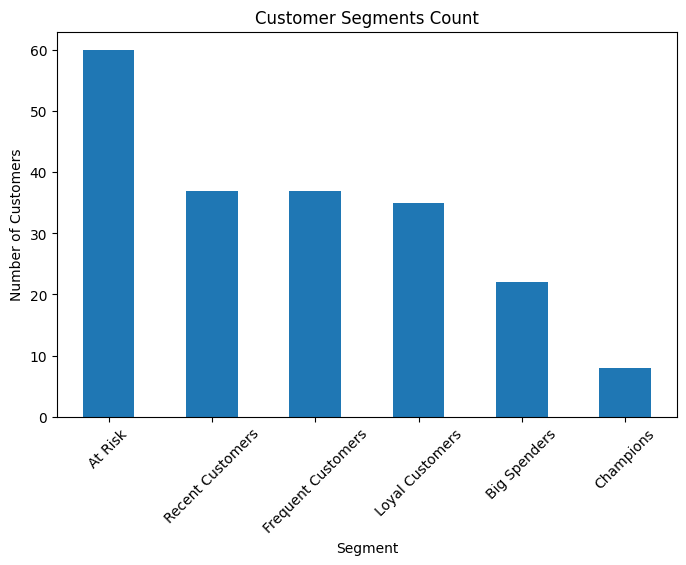

In [ ]:
plt.figure(figsize=(8,5))
rfm["Segment"].value_counts().plot(kind="bar")
plt.title("Customer Segments Count")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

In [ ]:
rfm['Segment'].value_counts()

,count
Segment,
At Risk,60
Recent Customers,37
Frequent Customers,37
Loyal Customers,35
Big Spenders,22
Champions,8


In [ ]:
rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
})

Recency Frequency     Monetary      
                          mean      mean         mean count
Segment                                                    
At Risk             136.400000  2.083333  1996.876167    60
Big Spenders        108.818182  2.681818  4934.130000    22
Champions             7.250000  4.000000  6319.323750     8
Frequent Customers   82.513514  3.459459  4260.739189    37
Loyal Customers      17.800000  3.514286  4152.408286    35
Recent Customers     19.135135  2.324324  2921.510811    37

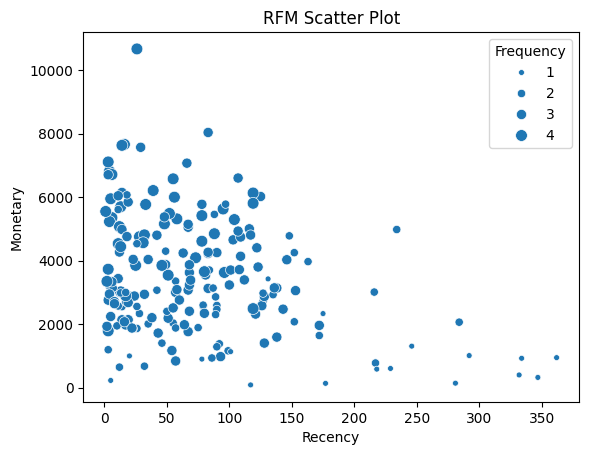

In [39]:
plt.figure()
sns.scatterplot(x='Recency', y='Monetary', size='Frequency', data=rfm)
plt.title('RFM Scatter Plot')
plt.show()

In [32]:
rfm.groupby('Segment').agg({
    'Monetary':'sum'
})

,Monetary
Segment,
At Risk,119812.57
Big Spenders,108550.86
Champions,50554.59
Frequent Customers,157647.35
Loyal Customers,145334.29
Recent Customers,108095.90


In [33]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [35]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [36]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,Cluster
CustomerID,,,,,,,,,
C0001,57,2,3354.52,3,1,3,313,At Risk,1
C0002,26,2,1862.74,4,1,1,411,Recent Customers,1
C0003,127,2,2725.38,1,1,2,112,At Risk,3
C0004,6,4,5354.88,5,4,5,545,Loyal Customers,0
C0005,55,2,2034.24,3,1,2,312,At Risk,1


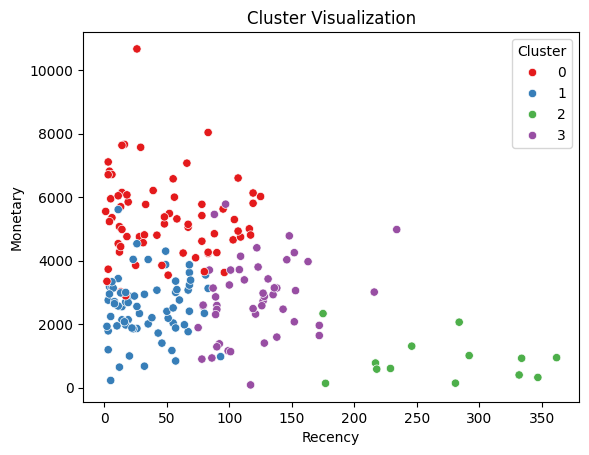

In [37]:
plt.figure()
sns.scatterplot(x='Recency', y='Monetary', hue='Cluster', data=rfm, palette='Set1')
plt.title('Cluster Visualization')
plt.show()

# From the above data we can answer these question

**Which segment produces the most revenue**

Frequent customer segmant produces the high revenue  of **1,57,647**

**Which customers are at risk**

customer who any one of the RFM score is no greater than or equal to 4

**Which customers should receive rewards**

customer with low Recency value and high monetary and frequnecy value,because we want to coustmer take those type customer to back

**Which customers should receive discounts**


top priority for the discount is At Risk customer,Hibernating Customer,then new customer also

**Which customers should receive re-engagement messages**

Focus especially on previously valuable customers who stopped purchasing, as they offer the highest return when reactivated.

**Which customers should be excluded from expensive campaigns**

Customers with low value and low engagement like Hibernating,At Risk Customer

In [42]:
df.to_csv("updated_transaction.csv",index=False)